In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
os.listdir('/content/drive/MyDrive')


['Colab Notebooks',
 'Translitrate.csv',
 'your_file_with_source_target.csv',
 'Document from V',
 'train.csv']

**Import Required Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/train.csv')


**Load Dataset**

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/train.csv')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


**Data Understanding**

In [ ]:
df.shape
df.columns
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


**Check Missing Values**

In [ ]:
df.isnull().sum()


,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


**Data Cleaning**
Remove duplicates

In [ ]:
df = df.drop_duplicates()


Handle missing values

In [ ]:
df['Postal Code'] = df['Postal Code'].fillna(df['Postal Code'].mode()[0])


**Convert Date Columns**

In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y')

**Feature Engineering**

In [ ]:
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days


Outlier Detection & Handling Boxplot for Sales

In [ ]:
sns.boxplot(x=df['Order'])
plt.show()


NameError: name 'sns' is not defined

**Exploratory Data Analysis (EDA)**

Sales Distribution

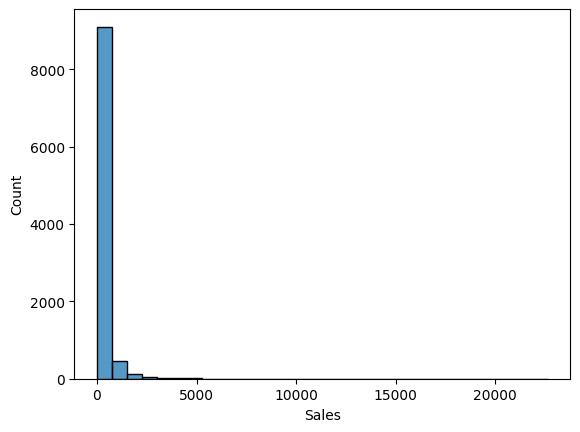

In [ ]:
sns.histplot(df['Sales'], bins=30)
plt.show()


Remove Outliers (IQR Method)

In [ ]:
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['Sales'] >= Q1 - 1.5*IQR) & (df['Sales'] <= Q3 + 1.5*IQR)]


Encoding Categorical Features

In [ ]:
df_encoded = pd.get_dummies(
    df[['Ship Mode','Segment','Region','Category']],
    drop_first=True
)


Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(
    df[['Sales','Shipping Days']]
)


Sales by Category

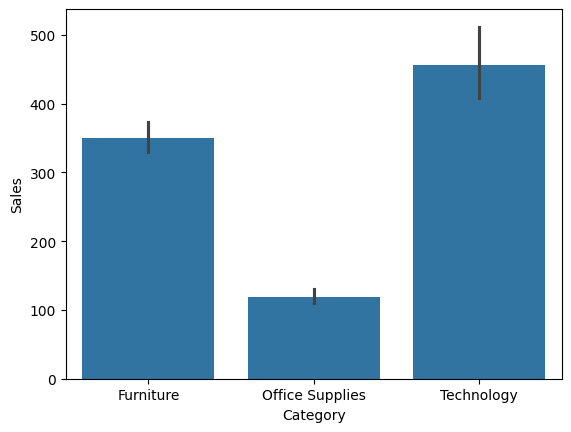

In [ ]:
sns.barplot(x='Category', y='Sales', data=df)
plt.show()


**Select Features & Target**

(Example: Predict Sales)

In [ ]:
X = df[['Order Month', 'Order Year', 'Shipping Days']]
y = df['Sales']


**Train-Test Split**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


**Model Selection & Training**

Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

Model Prediction

In [ ]:
y_pred = model.predict(X_test)


Model Evaluation

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))


MAE: 303.0079436473114
MSE: 670683.7949191055
R2 Score: -0.0034171061267833647


Visualization of Results

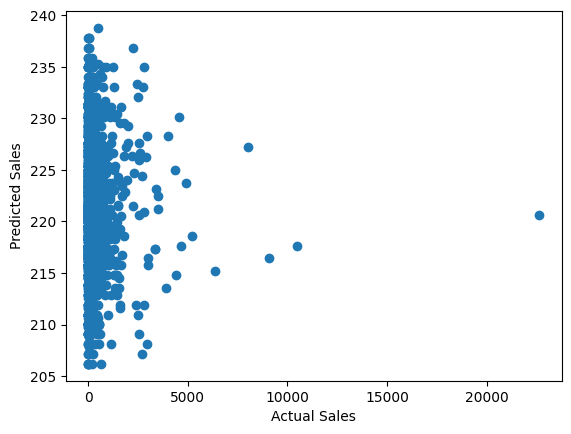

In [ ]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.show()


Save Model

In [ ]:
import joblib
joblib.dump(model, "sales_prediction_model.pkl")


['sales_prediction_model.pkl']

Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)


Compare Models

In [ ]:
print("Linear R2:", r2_score(y_test, y_pred))
print("Random Forest R2:", r2_score(y_test, rf_pred))


Linear R2: -0.0034171061267833647
Random Forest R2: -0.03165447490674822


Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators':[50,100],
    'max_depth':[None,10,20]
}

grid = GridSearchCV(RandomForestRegressor(), param_grid, cv=3)
grid.fit(X_train, y_train)


GridSearchCV(cv=3, estimator=RandomForestRegressor(),
             param_grid={'max_depth': [None, 10, 20],
                         'n_estimators': [50, 100]})

Business Insights Extraction

In [ ]:
df.groupby('Category')['Sales'].sum().sort_values(ascending=False)


,Sales
Category,
Office Supplies,337978.7500
Furniture,243370.4348
Technology,225412.1850


In [ ]:
df.groupby('Region')['Sales'].mean()


,Sales
Region,
Central,89.035275
East,93.308364
South,91.024184
West,97.286124


Time-Series Analysis

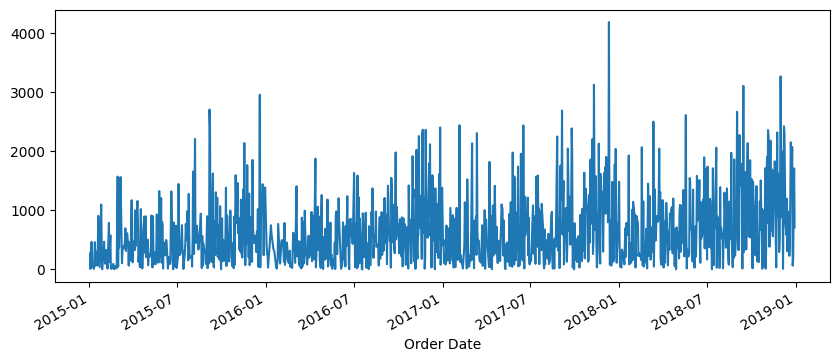

In [ ]:
sales_time = df.groupby('Order Date')['Sales'].sum()

sales_time.plot(figsize=(10,4))
plt.show()


Model Interpretation

In [ ]:
rf.feature_importances_


array([0.42192439, 0.34966941, 0.2284062 ])

Cross Validation

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X, y, cv=5)
scores.mean()


np.float64(-0.0574223170600797)

In [ ]:
import joblib

# Specify the path in your Google Drive
model_path = '/content/drive/MyDrive/sales_prediction_model.pkl'

# Save the model
joblib.dump(model, model_path)

print("Model saved to Google Drive successfully!")


Model saved to Google Drive successfully!
